# Kualitas Polusi Udara di Daerah Tuban

## Latar Belakang

Udara merupakan komponen ekosistem yang sangat vital bagi kelangsungan hidup manusia dan makhluk hidup lainnya. Namun, seiring dengan pesatnya pertumbuhan ekonomi dan pembangunan wilayah, kualitas udara menghadapi tantangan besar akibat meningkatnya polusi.

Kabupaten Tuban dikenal sebagai salah satu pusat pertumbuhan industri dan ekonomi strategis di jalur Pantura Jawa Timur. Wilayah Tuban menjadi pusat dari berbagai aktivitas industri skala besar, mulai dari industri semen (PT Semen Indonesia/Solusi Bangun Indonesia), kawasan kilang minyak, aktivitas pertambangan batu kapur/tambang mineral, hingga industri manufaktur dan pergudangan pendukung.

Selain sektor industri, mobilitas transportasi darat di jalur logistik utama pantura serta aktivitas perkotaan turut menyumbang emisi gas kendaraan bermotor (seperti $CO$, $NO_2$, dan partikulat debu) Emisi dari cerobong asap pabrik, debu aktivitas industri, dan gas buang kendaraan melepaskan berbagai polutan berbahaya ke udara bebas, seperti Particulate Matter ($PM_{2.5}$ dan $PM_{10}$), Karbon Monoksida ($CO$), Nitrogen Dioksida ($NO_2$), Sulfur Dioksida ($SO_2$), dan Ozone ($O_3$).

Oleh karena itu, dalam tugas ini, dilakukan proses pengumpulan data (crawling) historis kualitas udara di wilayah Kabupaten Tuban dalam rentang waktu 1 tahun terakhir hingga 31 Agustus 2026.

## Bussiness Understanding
### 1. Tujuan
Tujuan utama dari analisis ini adalah untuk mengetahui, mengukur, dan memetakan tingkat serta tren kualitas udara di wilayah Kabupaten Tuban secara objektif. Analisis ini berfokus pada pengolahan data historis polusi udara meliputi parameter/fitur seperti $PM_{2.5}$, $PM_{10}$, $CO$, $NO_2$, $SO_2$, dan $O_3$ selama satu tahun terakhir hingga 31 Agustus 2026. 
    
Melalui pemanfaatan teknik crawling data dan visualisasi time series, analisis ini bertujuan untuk melihat pola tingkat polusi dan mengidentifikasi titik-titik waktu di mana kualitas udara mengalami penurunan yang signifikan di wilayah Tuban.

### 2. Manfaat
Hasil dari analisis kualitas udara ini diharapkan dapat memberikan berbagai manfaat , antara lain:

a. Memberikan informasi yang transparan dan mudah diakses mengenai kondisi kebersihan udara harian di Tuban, sehingga masyarakat dapat mengambil langkah pencegahan yang tepat (seperti menggunakan masker atau membatasi aktivitas luar ruangan saat indeks polusi tinggi)

b. Menjadi bahan masukan, referensi empiris, dan data pendukung bagi pemerintah dalam mengevaluasi kebijakan pengendalian emisi, baik dari sektor industri berat, pertambangan, maupun sektor transportasi darat di Kabupaten Tuban

c. Menyelesaikan tugas analisis pada matakuliah Proyek Sains Data

## Data Understanding
Tahap Data Understanding bertujuan untuk mengenali, mengeksplorasi, dan memahami karakteristik data yang telah dikumpulkan sebelum ke tahap analisis.

### 1. Sumber Data dan Batasan Wilayah
Data historis kualitas udara diambil melalui API penyedia data lingkungan dan cuaca global yang valid. Pada data yang diambil terdapat parameter/fitur polutan seperti $PM_{2.5}$, $PM_{10}$, $CO$, $NO_2$, $SO_2$, dan $O_3$. Tetapi untuk parameter $PM_{2.5}$ dan $PM_{10}$ tidak dapat diukur secara langsung oleh satelit observasi kolom atmosfer murni (seperti Sentinel-5P)

Untuk memastikan spesifik titik pengambilan data hanya mencakup wilayah Kabupaten Tuban maka titik koordinat diambil menggunakan GeoJson. Rentang waktu data yang ditarik mencakup catatan historis selama satu tahun ke belakang hingga batas akhir tanggal 31 Agustus 2026.

#### Batasan Wilayah
Untuk batasan wilayah yang diambil adalah seperti gambar di bawah ini. Titik koordinat wilayah yang diambil nantinya digunakan untuk crawling data. Setelah mendapatkan titik koordinat sesuai wilayah langkah selanjutnya mengambil data.

![Foto Saya](img/geojson.png)

#### Pengambilan Data
**Dokumentasi pengambilan data:** https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

Note: Buat akun di website copernicus, lalu access JupyterLab dan pilih Python 3 (ipykernel)

##### 1. Install Library

In [25]:
pip install openeo

Note: you may need to restart the kernel to use updated packages.


##### 2. Import Library
Setelah proses instalasi selesai, kita memuat (import) library `openeo` ke dalam environment Python agar siap digunakan.

In [9]:
import openeo

##### 3. Autentikasi dan Koneksi ke Copernicus Data Space
Lakukan koneksi dan autentikasi ke server `openeo.dataspace.copernicus.eu` menggunakan sistem OIDC (OpenID Connect). Ikuti tautan yang muncul dan masukkan kode untuk menyelesaikan proses autentikasi.

In [10]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


##### 4. Koordinat Wilayah dan Pengambilan Data setiap Fitur
Koordinat area Tuban diperoleh dari https://geojson.io dengan Fitur yaitu $CO$, $NO2$, $SO2$, dan $O3$. Setiap fitur diproses supaya didapatkan data berupa `.csv`, lalu digabungkan masing masing fitur menjadi 1 file `.csv`.

###### 1. CO

In [29]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [111.70, -6.76],
            [111.70, -6.90],
            [112.03, -6.99],
            [112.19, -6.80],
            [111.70, -6.76],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 111.70,
        "south": -6.99,
        "east": 112.19,
        "north": -6.76
    },
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [30]:
job = s5p_co_aoi.execute_batch(title="Polutan CO in Tuban", outputfile="COInTuban.csv")

0:00:00 Job 'j-260827071650456ab548fcb4c9f19526': send 'start'
0:00:02 Job 'j-260827071650456ab548fcb4c9f19526': created (progress 0%)
0:00:07 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:00:14 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:00:22 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:00:31 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:00:44 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:00:59 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:01:18 Job 'j-260827071650456ab548fcb4c9f19526': queued (progress 0%)
0:01:42 Job 'j-260827071650456ab548fcb4c9f19526': running (progress N/A)
0:02:12 Job 'j-260827071650456ab548fcb4c9f19526': running (progress N/A)
0:02:50 Job 'j-260827071650456ab548fcb4c9f19526': running (progress N/A)
0:03:36 Job 'j-260827071650456ab548fcb4c9f19526': running (progress N/A)
0:04:35 Job 'j-260827071650456ab548fcb4c9f19526': finished (progress 100%)


###### 2. NO2

In [31]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [111.70, -6.76],
            [111.70, -6.90],
            [112.03, -6.99],
            [112.19, -6.80],
            [111.70, -6.76],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 111.70,
        "south": -6.99,
        "east": 112.19,
        "north": -6.76
    },
    bands=["NO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [32]:
job = s5p_no2_aoi.execute_batch(title="Polutan NO2 in Tuban", outputfile="NO2InTuban.csv")

0:00:00 Job 'j-2608270721264448965d41ee12aa2910': send 'start'
0:00:02 Job 'j-2608270721264448965d41ee12aa2910': created (progress 0%)
0:00:07 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:00:13 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:00:21 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:00:31 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:00:43 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:00:58 Job 'j-2608270721264448965d41ee12aa2910': queued (progress 0%)
0:01:17 Job 'j-2608270721264448965d41ee12aa2910': running (progress N/A)
0:01:41 Job 'j-2608270721264448965d41ee12aa2910': running (progress N/A)
0:02:11 Job 'j-2608270721264448965d41ee12aa2910': running (progress N/A)
0:02:49 Job 'j-2608270721264448965d41ee12aa2910': running (progress N/A)
0:03:35 Job 'j-2608270721264448965d41ee12aa2910': finished (progress 100%)


###### 3. SO2

In [34]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [111.70, -6.76],
            [111.70, -6.90],
            [112.03, -6.99],
            [112.19, -6.80],
            [111.70, -6.76],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 111.70,
        "south": -6.99,
        "east": 112.19,
        "north": -6.76
    },
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [35]:
job = s5p_so2_aoi.execute_batch(title="Polutan SO2 in Tuban", outputfile="SO2InTuban.csv")

0:00:00 Job 'j-2608270725264ad991bbfe189f2db533': send 'start'
0:00:02 Job 'j-2608270725264ad991bbfe189f2db533': created (progress 0%)
0:00:07 Job 'j-2608270725264ad991bbfe189f2db533': queued (progress 0%)
0:00:13 Job 'j-2608270725264ad991bbfe189f2db533': queued (progress 0%)
0:00:21 Job 'j-2608270725264ad991bbfe189f2db533': queued (progress 0%)
0:00:31 Job 'j-2608270725264ad991bbfe189f2db533': queued (progress 0%)
0:00:43 Job 'j-2608270725264ad991bbfe189f2db533': queued (progress 0%)
0:00:59 Job 'j-2608270725264ad991bbfe189f2db533': running (progress N/A)
0:01:18 Job 'j-2608270725264ad991bbfe189f2db533': running (progress N/A)
0:01:42 Job 'j-2608270725264ad991bbfe189f2db533': running (progress N/A)
0:02:11 Job 'j-2608270725264ad991bbfe189f2db533': running (progress N/A)
0:02:49 Job 'j-2608270725264ad991bbfe189f2db533': running (progress N/A)
0:03:36 Job 'j-2608270725264ad991bbfe189f2db533': finished (progress 100%)


###### 4. O3

In [36]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [111.70, -6.76],
            [111.70, -6.90],
            [112.03, -6.99],
            [112.19, -6.80],
            [111.70, -6.76],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 111.70,
        "south": -6.99,
        "east": 112.19,
        "north": -6.76
    },
    bands=["O3"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_o3_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_o3_aoi = s5p_o3_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [37]:
job = s5p_o3_aoi.execute_batch(title="Polutan O3 in Tuban", outputfile="O3InTuban.csv")

0:00:00 Job 'j-2608270729304205b7c519c7be9f547d': send 'start'
0:00:02 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:07 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:13 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:21 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:31 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:43 Job 'j-2608270729304205b7c519c7be9f547d': queued (progress 0%)
0:00:59 Job 'j-2608270729304205b7c519c7be9f547d': running (progress N/A)
0:01:18 Job 'j-2608270729304205b7c519c7be9f547d': running (progress N/A)
0:01:42 Job 'j-2608270729304205b7c519c7be9f547d': running (progress N/A)
0:02:12 Job 'j-2608270729304205b7c519c7be9f547d': running (progress N/A)
0:02:49 Job 'j-2608270729304205b7c519c7be9f547d': running (progress N/A)
0:03:36 Job 'j-2608270729304205b7c519c7be9f547d': finished (progress 100%)


Dari semua fitur yang sudah dijalankan, maka didapatkan semua file `.csv` dari setiap fiturnya. Lalu untuk pemeriksaan file `.csv` maka dilakukan penggabungan dari beberapa file dan penggabungan dilakukan secara manual.

![Foto Saya](img/csvpolutan.png)

### 2. Deskripsi Fitur
Berdasarkan file `.csv` hasil crawling data kualitas udara yang ada di Kabupaten Tuban yang telah dibatasi menggunakan GeoJson, terdapat kolom parameter/fitur yang menunjukkan polutan serta parameter waktu. Berikut merupakan deskripsi setiap parameter/fitur yang terdapat di wilayah Kabupaten Tuban:

#### a. Karbon Monoksida (CO) 
Karbon Monoksida (CO) adalah gas beracun yang tidak berwarna, tidak berbau, tidak berasa. Gas ini terbentuk akibat proses pembakaran karbon atau bahan bakar yang tidak sempurna, selain itu juga akibat dari emisi gas buang dari kendaraan bermotor yang padat di jalan raya, kemacetan lalu lintas, serta proses pembakaran dari fasilitas industri atau genset. Dalam konsentrasi tinggi, CO dapat mengikat oksigen dalam darah secara berlebihan sehingga membahayakan kesehatan manusia.

#### b. Nitrogen Dioksida (NO2)
Nitrogen Dioksida (NO2) adalah gas beracun berwarna coklat kemerahan dengan bau yang tajam dan menyengat. Gas ini berkontribusi besar terhadap penurunan kualitas udara perkotaan dan pembentukan kabut asap (smog) serta hujan asam.

#### c. Sulfur Dioksida (SO2)
Sulfur Dioksida (SO2) adalah gas berbau tajam dan menyesakkan yang dilepaskan ketika material atau bahan bakar yang mengandung sulfur dibakar. Gas ini dapat memicu gangguan pernapasan, terutama bagi penderita asma. Proses pembakaran bahan bakar fosil yang mengandung sulfur (seperti batu bara atau minyak industri) serta aktivitas dari sektor industri berat dan peleburan.

#### d. Ozone (O3)
Ozone (O3) terbentuk melalui reaksi kimia atmosfer antara polutan pendahulu (seperti $NO_2$ dan senyawa organik volatil) yang bereaksi di bawah paparan sinar matahari terik, yang kerap ditemui di wilayah terbuka atau kawasan industri dan perkotaan.


### 3. Eksplorasi Data
Tahap eksplorasi data digunakan untuk menggali mengenai informasi awal, memahami karakteristik data, dan memastikan file .csv hasil crawling data polusi udara di Kabupaten Tuban. 

#### a. Pemeriksaan Struktur dan Tipe Data
File `.csv` hasil crawling akan dilakukan pengecekan jumlah baris dan kolom pada tiap polutannya untuk memastikan rentang waktu data dari satu tahun ke belakang hingga tanggal 31 Agustus 2026 telah terhimpun secara utuh.

In [42]:
import pandas as pd

# Membaca data
df = pd.read_csv("KualitasUdaraTuban.csv")

df['date'] = pd.to_datetime(df['date'])

print("=== INFORMASI STRUKTUR & TIPE DATA KOLOM ===")
df.info()

=== INFORMASI STRUKTUR & TIPE DATA KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    366 non-null    datetime64[ns, UTC]
 1   CO      271 non-null    float64            
 2   NO2     279 non-null    float64            
 3   SO2     305 non-null    float64            
 4   O3      358 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(4)
memory usage: 14.4 KB


#### b. Analisis Statistik Deskriptif 
Pada analisis deskriptif ini terdapat informasi mengenai data dalam setiap fitur, yaitu:

**count:** Jumlah total catatan data yang valid dan tidak kosong untuk masing-masing parameter gas polutan

**mean:** Menjelaskan tingkat konsentrasi rata-rata harian dari gas polutan ($CO$, $NO_2$, $SO_2$, $O_3$) di wilayah Kabupaten Tuban selama rentang waktu satu tahun hingga 31 Agustus 2026

**std:** Menunjukkan tingkat penyebaran atau fluktuasi data dari nilai rata-ratanya. Semakin besar nilai std, berarti konsentrasi polutan tersebut sangat fluktuatif (kadang sangat rendah, kadang tiba-tiba tinggi)

**min&max:** Menunjukkan titik terendah pencatatan dan titik lonjakan tertinggi (puncak polusi)

**median:** Merupakan nilai tengah yang mencerminkan kondisi kualitas udara di Kabupaten Tuban sehari-hari.

In [43]:
import pandas as pd

df = pd.read_csv("KualitasUdaraTuban.csv")

stat_desc = df.describe().T

stat_desc['median'] = df.median(numeric_only=True)

stat_desc = stat_desc[['count', 'mean', 'std', 'min', '50%', 'max']]
stat_desc = stat_desc.rename(columns={'50%': 'median'})

print("--- TABEL STATISTIK DESKRIPTIF KUALITAS UDARA TUBAN ---")
print(stat_desc)

--- TABEL STATISTIK DESKRIPTIF KUALITAS UDARA TUBAN ---
     count      mean       std       min    median       max
CO   271.0  0.029867  0.003505  0.021378  0.029592  0.043252
NO2  279.0  0.000040  0.000012  0.000013  0.000039  0.000095
SO2  305.0  0.000039  0.000099 -0.000418  0.000033  0.000394
O3   358.0  0.115835  0.002528  0.109691  0.115534  0.122904


#### c. Pengecekan Missing Values
Pengecekan missing values ini dilakukan untuk mengetahui apakah data yang ada memiliki nilai yang kosong/hilang akibat proses crawling.

Jika ditemukan adanya missing values, penanganan lanjutan akan dilakukan seperti menggunakan metode interpolation, tetapi itu pada bagian PreProsesing Data. Jadi untuk kali ini hanya mengetahui apakah ada missing values atau tidak


In [44]:
import pandas as pd

# 1. Membaca file CSV
df = pd.read_csv("KualitasUdaraTuban.csv")

# 2. Cek jumlah missing value di setiap kolom
missing_count = df.isnull().sum()

# 3. Hitung persentase missing value dari total baris
missing_percentage = (df.isnull().sum() / len(df)) * 100

# 4. Gabungkan dalam satu tabel ringkasan agar mudah dibaca
df_missing_summary = pd.DataFrame({
    'Jumlah Missing Value': missing_count,
    'Persentase (%)': missing_percentage
})

print("--- LAPORAN PENGECEKAN MISSING VALUE ---")
print(df_missing_summary)

# 5. Cek apakah ada baris di mana kolom tanggalnya (date) kosong
missing_dates_count = df['date'].isnull().sum()
print(f"\nJumlah baris dengan tanggal kosong: {missing_dates_count}")

--- LAPORAN PENGECEKAN MISSING VALUE ---
      Jumlah Missing Value  Persentase (%)
date                     0        0.000000
CO                      95       25.956284
NO2                     87       23.770492
SO2                     61       16.666667
O3                       8        2.185792

Jumlah baris dengan tanggal kosong: 0


#### d. Deteksi Data Aneh (Outliers)
Kadar polusi udara bisa saja memiliki anomali atau outlier (lonjakan atau penurunan drastis) akibat cuaca atau kesalahan sensor. Kita mendeteksi anomali ini menggunakan metode Interquartile Range (IQR) dengan menentukan batas bawah (lower bound) dan batas atas (upper bound).

In [45]:
import pandas as pd

# Membaca data gabungan kualitas udara Tuban
df = pd.read_csv("KualitasUdaraTuban.csv")

# Daftar kolom fitur polutan yang akan dicek outlier-nya
# (Sesuaikan dengan nama kolom polutan yang ada di DataFrame Anda)
fitur_polutan = ['CO', 'NO2', 'SO2', 'O3']

for kolom in fitur_polutan:
    if kolom in df.columns:
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        outliers_iqr = df[
            (df[kolom] < lower_bound) | 
            (df[kolom] > upper_bound)
        ]

        print(f"=== Parameter: {kolom} ===")
        print(f"Jumlah Outlier : {len(outliers_iqr)}")
        if len(outliers_iqr) > 0:
            print(outliers_iqr[['date', kolom]].head())
        print("-" * 35 + "\n")

=== Parameter: CO ===
Jumlah Outlier : 4
                         date        CO
25   2025-09-24T00:00:00.000Z  0.038771
38   2025-10-07T00:00:00.000Z  0.043252
40   2025-10-09T00:00:00.000Z  0.040070
349  2026-08-14T00:00:00.000Z  0.039073
-----------------------------------

=== Parameter: NO2 ===
Jumlah Outlier : 2
                         date       NO2
181  2026-02-27T00:00:00.000Z  0.000095
185  2026-03-03T00:00:00.000Z  0.000074
-----------------------------------

=== Parameter: SO2 ===
Jumlah Outlier : 15
                         date       SO2
51   2025-10-20T00:00:00.000Z -0.000227
65   2025-11-03T00:00:00.000Z -0.000201
131  2026-01-08T00:00:00.000Z  0.000349
172  2026-02-18T00:00:00.000Z -0.000318
201  2026-03-19T00:00:00.000Z  0.000252
-----------------------------------

=== Parameter: O3 ===
Jumlah Outlier : 2
                         date        O3
344  2026-08-09T00:00:00.000Z  0.122904
345  2026-08-10T00:00:00.000Z  0.122870
-----------------------------------



### 4. Visualisasi

In [48]:
pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 46.2 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 26.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 61.4 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 88.0 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 17.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


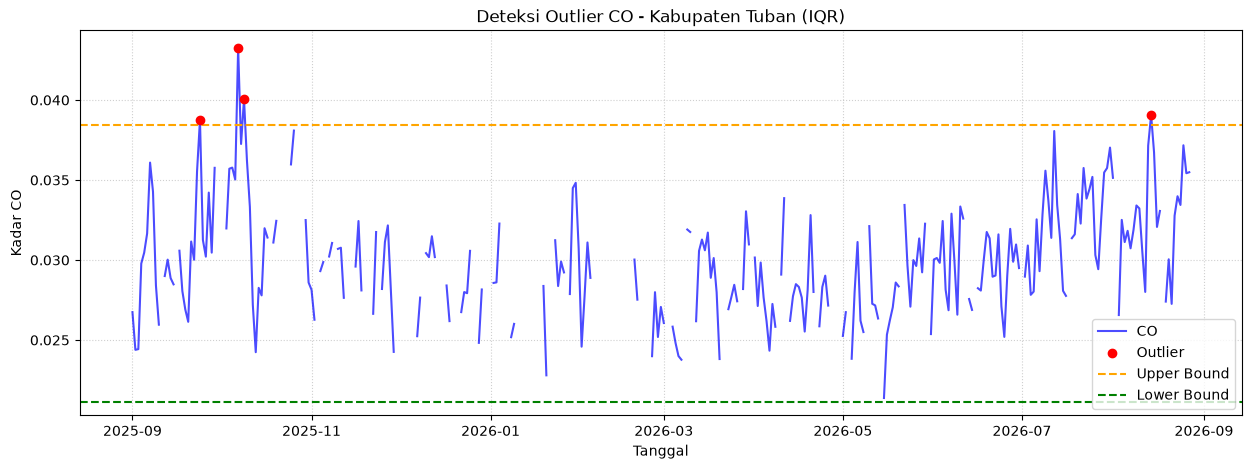

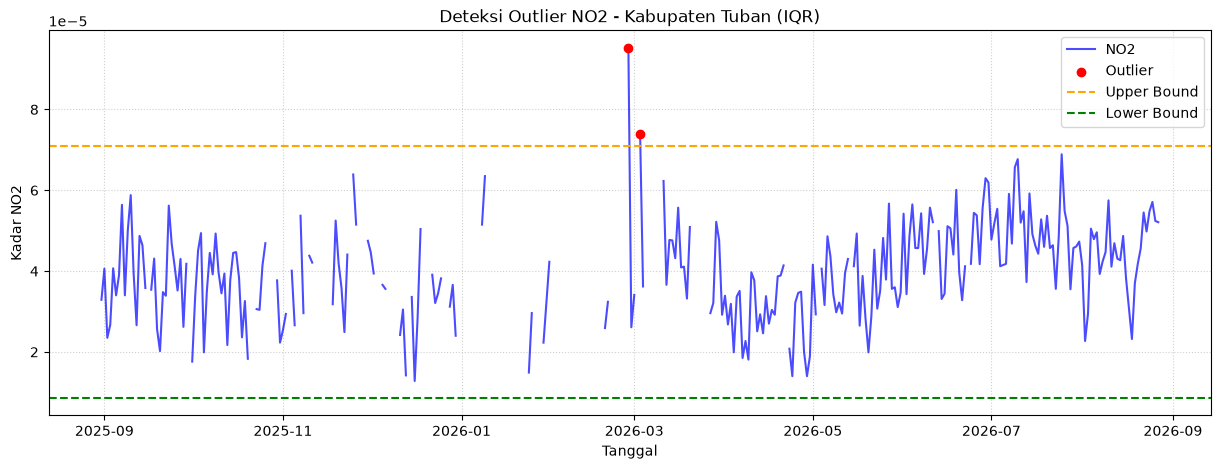

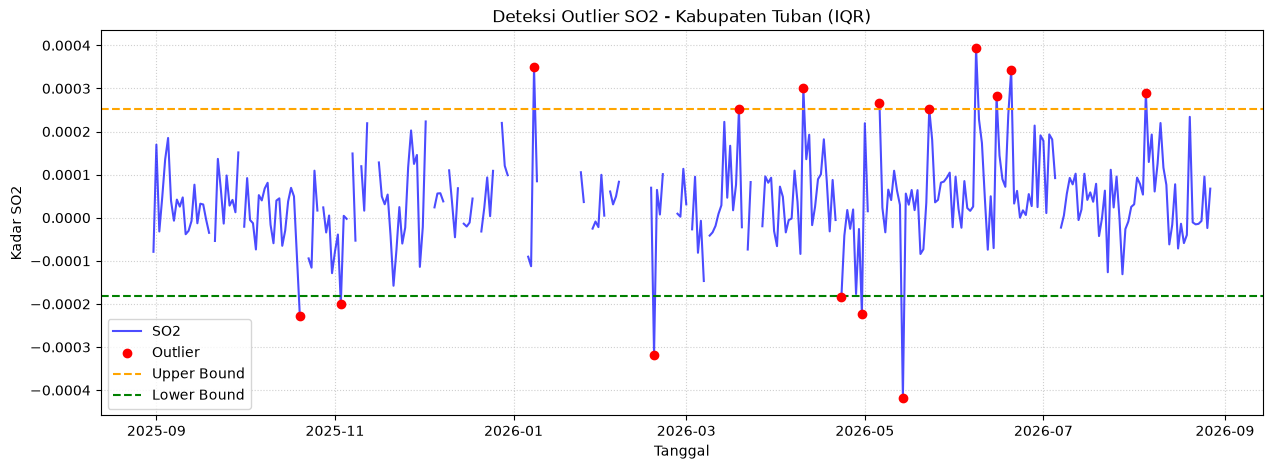

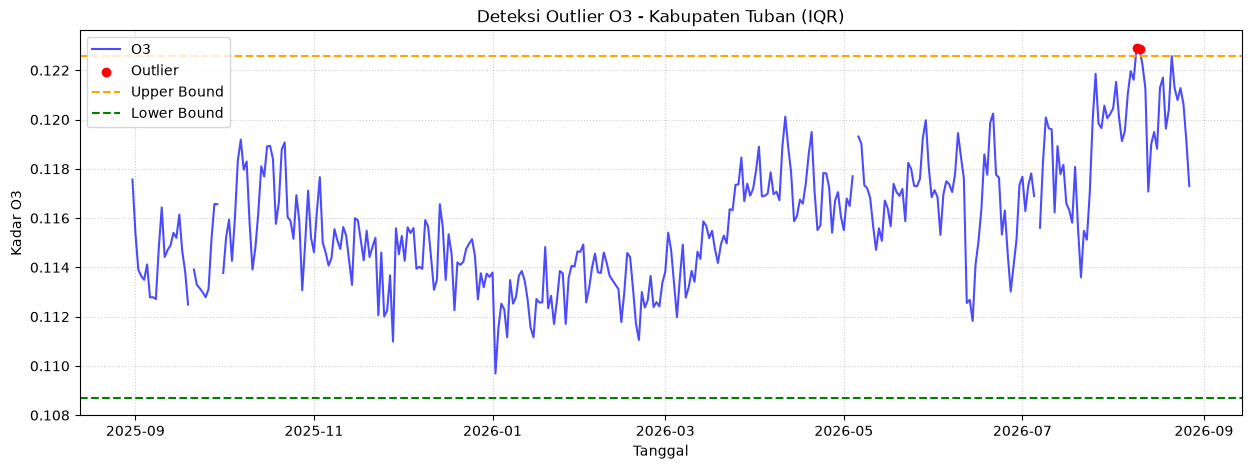

In [49]:
import matplotlib.pyplot as plt

# Pastikan kolom date sudah bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Daftar fitur polutan yang ingin divisualisasikan
fitur_polutan = ['CO', 'NO2', 'SO2', 'O3']

for kolom in fitur_polutan:
    if kolom in df.columns:
        # Hitung ulang batas IQR untuk masing-masing kolom
        Q1 = df[kolom].quantile(0.25)
        Q3 = df[kolom].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)
        
        # Saring data outlier per kolom
        outliers_iqr = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]

        # Buat plot untuk setiap fitur
        plt.figure(figsize=(15, 5))
        
        plt.plot(
            df['date'],
            df[kolom],
            label=kolom,
            color='blue',
            alpha=0.7
        )

        plt.scatter(
            outliers_iqr['date'],
            outliers_iqr[kolom],
            color='red',
            label='Outlier',
            zorder=5
        )

        plt.axhline(
            upper_bound,
            color='orange',
            linestyle='dashed',
            label='Upper Bound'
        )

        plt.axhline(
            lower_bound,
            color='green',
            linestyle='dashed',
            label='Lower Bound'
        )

        plt.title(f"Deteksi Outlier {kolom} - Kabupaten Tuban (IQR)")
        plt.xlabel("Tanggal")
        plt.ylabel(f"Kadar {kolom}")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()